# Cell-cell communication analysis with CellChat

[CellChat](https://github.com/jinworks/CellChat) (Jin *et al.*, *Nat Commun* 2021; *Nat Protoc* 2025) infers cell-cell communication from a curated ligand-receptor database that models multi-subunit complexes, soluble agonists/antagonists and co-stimulatory/co-inhibitory receptors. Each interaction gets a **communication probability** from the trimean expression of ligand and receptor, and a **permutation p-value** from shuffling the cell labels.

`ov.single.run_cellchat` is a PyTorch re-implementation of the R workflow (`subsetData` → `identifyOverExpressedGenes` → `identifyOverExpressedInteractions` → `computeCommunProb` → `filterCommunication` → `computeCommunProbPathway` → `aggregateNet`) with CellChatDB v2 bundled — no R installation is needed. On real data it selects the same over-expressed genes and ligand-receptor pairs as R CellChat 2.2 and reproduces its communication probabilities to ~1e-15; only the permutation p-values differ by Monte-Carlo noise (different random number generator).

The result is stored in `adata.uns['cellchat_res']` and is read directly by `ov.pl.ccc_heatmap`, `ov.pl.ccc_network_plot` and `ov.pl.ccc_stat_plot`, so every plot from the [CellPhoneDB](t_ccc_cellphonedb.ipynb) and [LIANA+](t_ccc_liana.ipynb) tutorials works unchanged.

In [1]:
import pandas as pd
import omicverse as ov

ov.plot_set()

/scratch/users/steorra/env/cellgoal/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


/scratch/users/steorra/env/cellgoal/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.8   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the EVT dataset

We use the maternal-fetal interface dataset (decidual NK cells, dendritic cells and trophoblasts) from the CellPhoneDB tutorial, so the results can be compared with [the CellPhoneDB tutorial](t_ccc_cellphonedb.ipynb). Download `data_tutorial.zip` from the [CellPhoneDB repository](https://github.com/ventolab/CellphoneDB/tree/master/notebooks) and unzip it into `data/cpdb/`. The matrix is already library-size normalised and log-transformed, which is what CellChat expects.

In [2]:
adata = ov.read('data/cpdb/normalised_log_counts.h5ad')
keep = ['eEVT', 'iEVT', 'EVT_1', 'EVT_2', 'DC', 'dNK1', 'dNK2', 'dNK3',
        'VCT', 'VCT_CCC', 'VCT_fusing', 'VCT_p', 'GC', 'SCT']
adata = adata[adata.obs['cell_labels'].isin(keep)].copy()
adata

AnnData object with n_obs × n_vars = 1065 × 30800
    obs: 'n_genes', 'n_counts', 'cell_labels'
    var: 'gene_ids', 'feature_types'
    uns: 'neighbors_scVI_n_latent_14_sample_n_layers_3', 'neighbors_scVI_n_latent_20_sample_n_layers_3', 'umap'
    obsm: 'X_scVI_n_latent_14_sample_n_layers_3', 'X_scVI_n_latent_20_sample_n_layers_3', 'X_umap', 'X_umap_scVI_n_latent_14_sample_n_layers_3', 'X_umap_scVI_n_latent_20_sample_n_layers_3'
    obsp: 'neighbors_scVI_n_latent_14_sample_n_layers_3_connectivities', 'neighbors_scVI_n_latent_14_sample_n_layers_3_distances', 'neighbors_scVI_n_latent_20_sample_n_layers_3_connectivities', 'neighbors_scVI_n_latent_20_sample_n_layers_3_distances'

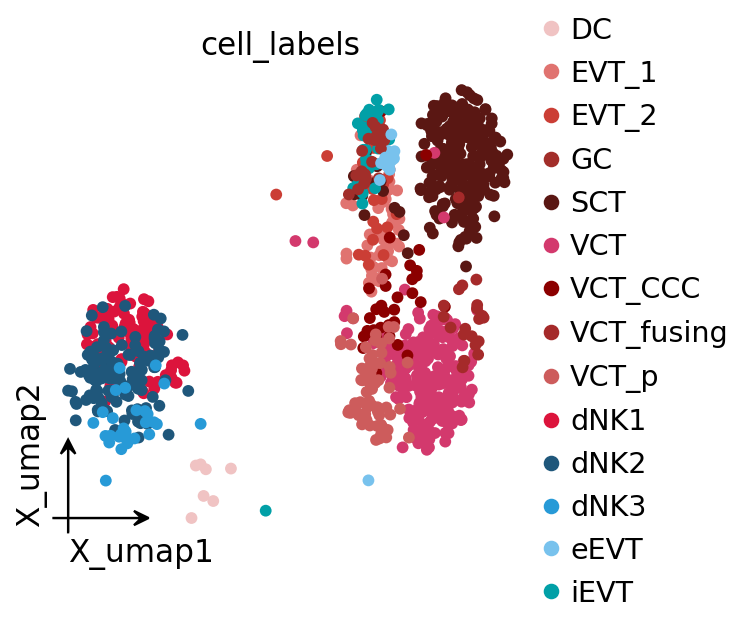

In [3]:
ov.pl.embedding(
    adata,
    basis='X_umap',
    color='cell_labels',
    frameon='small',
    palette=ov.pl.red_color + ov.pl.blue_color + ov.pl.green_color + ov.pl.orange_color + ov.pl.purple_color,
)

## 2. Run CellChat

The defaults follow R CellChat: the full human CellChatDB, triMean group averages, 100 permutations, and removal of groups with ≤ 10 cells (`min_cells`). Use `db_categories=['Secreted Signaling']` to restrict the database as R's `subsetDB` does, and `use_gpu=True` to run the permutations on a GPU.

In [4]:
adata = ov.single.run_cellchat(
    adata,
    groupby='cell_labels',
    species='human',
    n_perms=100,
    min_cells=10,
)

CellChat permutations:   0%|          | 0/100 [00:00<?, ?it/s]

`adata.uns['cellchat_res']` holds the full `(sender, receiver, LR)` probability and p-value tensors, the over-expressed LR table `LRsig`, the pathway-level network `netP`, and `df_net`, the table of significant interactions (R's `subsetCommunication`).

In [5]:
res = adata.uns['cellchat_res']
print(res['parameters']['n_LRsig'], 'over-expressed LR pairs;', len(res['df_net']), 'significant interactions')
print('Top pathways:', list(res['netP']['pathways'][:10]))
res['df_net'].sort_values('prob', ascending=False).head()

2194 over-expressed LR pairs; 5381 significant interactions
Top pathways: ['COLLAGEN', 'FN1', 'LAMININ', 'ADGRG', 'CypA', 'VEGF', 'MHC-I', 'SPP1', 'NCAM', 'HSPG']


,source,target,prob,pval,interaction_name,interaction_name_2,pathway_name,ligand,receptor,annotation,evidence
4467,eEVT,eEVT,0.295212,0.0,NCAM1_NCAM1,NCAM1 - NCAM1,NCAM,NCAM1,NCAM1,Cell-Cell Contact,KEGG: hsa04514
2025,GC,GC,0.223084,0.0,FN1_ITGA5_ITGB1,FN1 - (ITGA5+ITGB1),FN1,FN1,ITGA5_ITGB1,ECM-Receptor,KEGG: hsa04512
2029,GC,iEVT,0.215276,0.0,FN1_ITGA5_ITGB1,FN1 - (ITGA5+ITGB1),FN1,FN1,ITGA5_ITGB1,ECM-Receptor,KEGG: hsa04512
2065,iEVT,GC,0.213430,0.0,FN1_ITGA5_ITGB1,FN1 - (ITGA5+ITGB1),FN1,FN1,ITGA5_ITGB1,ECM-Receptor,KEGG: hsa04512
2069,iEVT,iEVT,0.205869,0.0,FN1_ITGA5_ITGB1,FN1 - (ITGA5+ITGB1),FN1,FN1,ITGA5_ITGB1,ECM-Receptor,KEGG: hsa04512


DC has only 7 cells, so — exactly as R's `filterCommunication` — all of its interactions are removed. `ov.single.cellchat_subset_communication` filters the significant interactions by sender, receiver or pathway:

In [6]:
ov.single.cellchat_subset_communication(
    adata, sources=['eEVT'], signaling=['TGFb'],
)

,source,target,prob,pval,interaction_name,interaction_name_2,pathway_name,ligand,receptor,annotation,evidence
0,eEVT,eEVT,0.000380,0.02,TGFB1_ACVR1_TGFBR1,TGFB1 - (ACVR1+TGFBR1),TGFb,TGFB1,ACVR1_TGFbR,Secreted Signaling,PMID: 29376829
1,eEVT,GC,0.001001,0.05,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,TGFB1,TGFbR1_R2,Secreted Signaling,KEGG: hsa04350
2,eEVT,iEVT,0.001182,0.00,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,TGFB1,TGFbR1_R2,Secreted Signaling,KEGG: hsa04350
3,eEVT,eEVT,0.001324,0.00,TGFB2_ACVR1_TGFBR1,TGFB2 - (ACVR1+TGFBR1),TGFb,TGFB2,ACVR1_TGFbR,Secreted Signaling,PMID: 29376829
4,eEVT,EVT_2,0.000757,0.00,TGFB2_TGFBR1_TGFBR2,TGFB2 - (TGFBR1+TGFBR2),TGFb,TGFB2,TGFbR1_R2,Secreted Signaling,KEGG: hsa04350
5,eEVT,GC,0.003471,0.00,TGFB2_TGFBR1_TGFBR2,TGFB2 - (TGFBR1+TGFBR2),TGFb,TGFB2,TGFbR1_R2,Secreted Signaling,KEGG: hsa04350
6,eEVT,VCT,0.001284,0.00,TGFB2_TGFBR1_TGFBR2,TGFB2 - (TGFBR1+TGFBR2),TGFb,TGFB2,TGFbR1_R2,Secreted Signaling,KEGG: hsa04350
7,eEVT,VCT_fusing,0.000597,0.00,TGFB2_TGFBR1_TGFBR2,TGFB2 - (TGFBR1+TGFBR2),TGFb,TGFB2,TGFbR1_R2,Secreted Signaling,KEGG: hsa04350
8,eEVT,eEVT,0.001082,0.00,TGFB2_TGFBR1_TGFBR2,TGFB2 - (TGFBR1+TGFBR2),TGFb,TGFB2,TGFbR1_R2,Secreted Signaling,KEGG: hsa04350
9,eEVT,iEVT,0.004096,0.00,TGFB2_TGFBR1_TGFBR2,TGFB2 - (TGFBR1+TGFBR2),TGFb,TGFB2,TGFbR1_R2,Secreted Signaling,KEGG: hsa04350


## 3. Prepare plotting helpers

In [7]:
comm_adata = ov.single.format_cellchat_results(adata)
comm_adata

AnnData object with n_obs × n_vars = 196 × 2194
    obs: 'sender', 'receiver', 'cell_type_pair'
    var: 'interaction_name', 'interaction_name_2', 'interacting_pair', 'classification', 'gene_a', 'gene_b', 'annotation', 'evidence'
    uns: 'comm_source', 'cellchat_parameters'
    layers: 'means', 'pvalues'

In [8]:
cell_types = adata.obs['cell_labels'].cat.categories
palette = ov.pl.red_color + ov.pl.blue_color + ov.pl.green_color + ov.pl.orange_color + ov.pl.purple_color
color_dict = dict(zip(cell_types, palette[:len(cell_types)]))
focus_pathway, focus_pair_lr, focus_ligand = 'TGFb', 'TGFB1_TGFBR1_TGFBR2', 'TGFB1'

In [9]:
umap_df = pd.DataFrame(adata.obsm['X_umap'][:, :2], columns=['x', 'y'], index=adata.obs_names)
umap_df['cell_type'] = adata.obs['cell_labels'].astype(str).values
node_positions = umap_df.groupby('cell_type')[['x', 'y']].median().apply(tuple, axis=1).to_dict()

# 1. `ov.pl.ccc_heatmap`
## 1.1 Aggregated and focused heatmaps

Passing `adata` is enough: the plotting functions find `adata.uns['cellchat_res']` and convert it on the fly. The aggregated heatmap sums the probabilities of all LR pairs per sender-receiver pair.

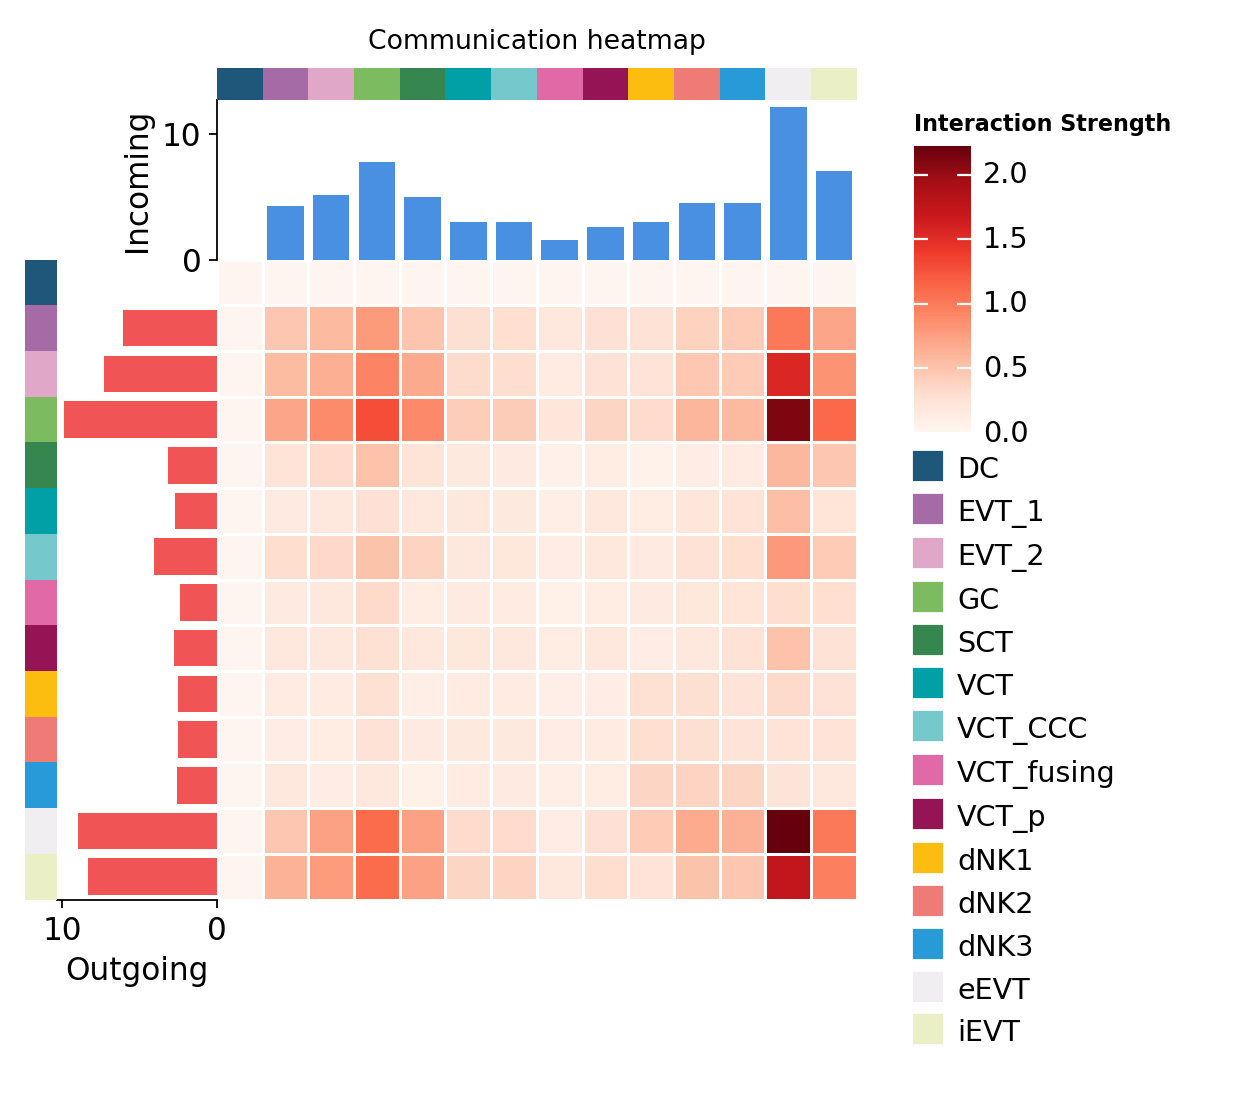

In [10]:
fig, ax = ov.pl.ccc_heatmap(
    adata, plot_type='heatmap', display_by='aggregation', cmap='Reds', show=False,
)

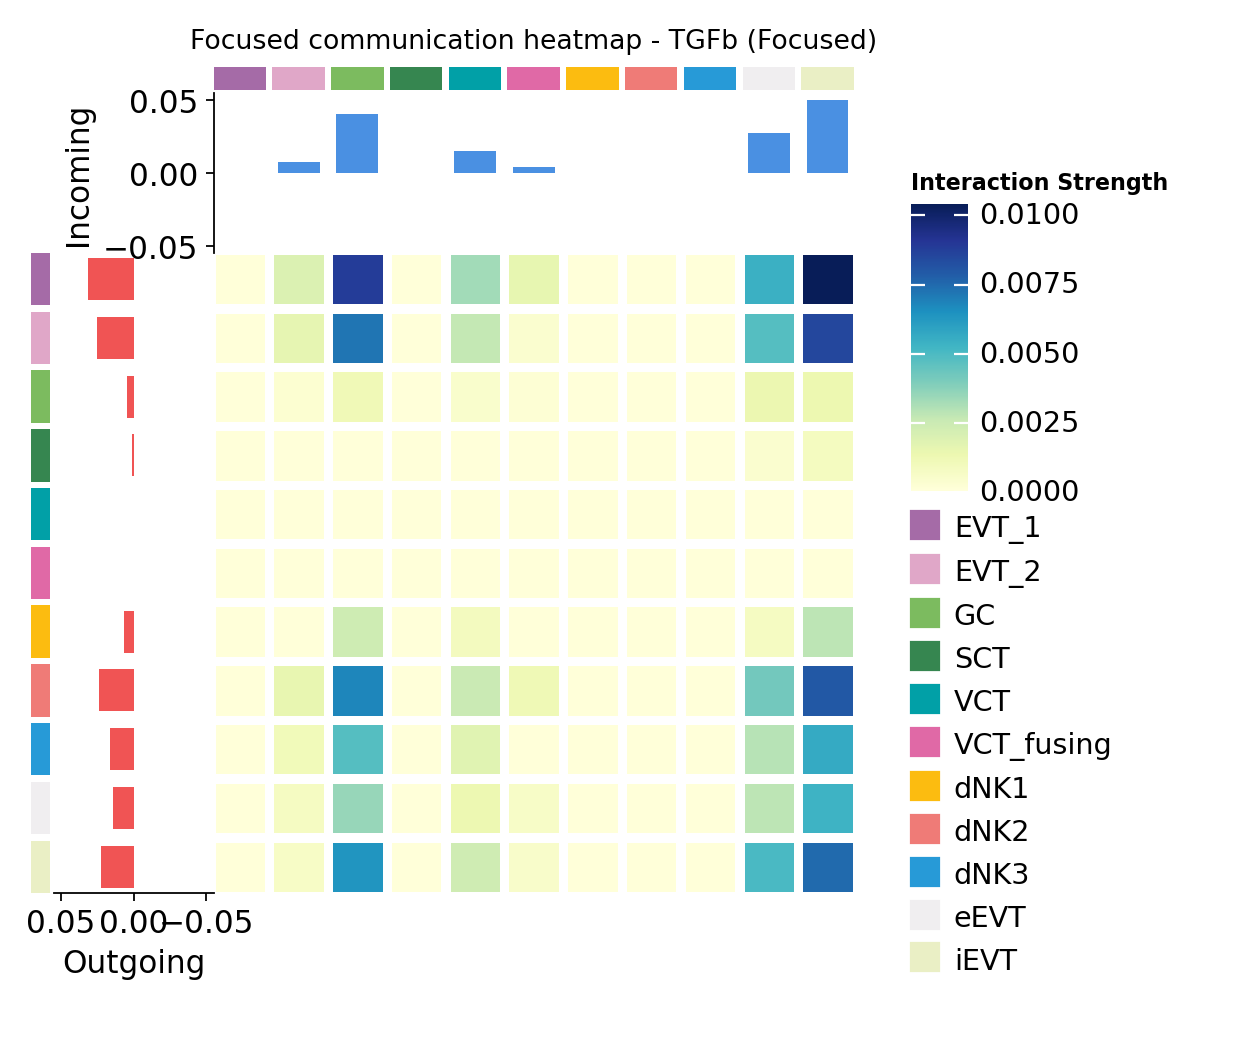

In [11]:
fig, ax = ov.pl.ccc_heatmap(
    adata, plot_type='focused_heatmap', signaling=[focus_pathway],
    cmap='YlGnBu', figsize=(7, 5), show=False,
)

## 1.2 Dot, pathway bubble and role heatmaps

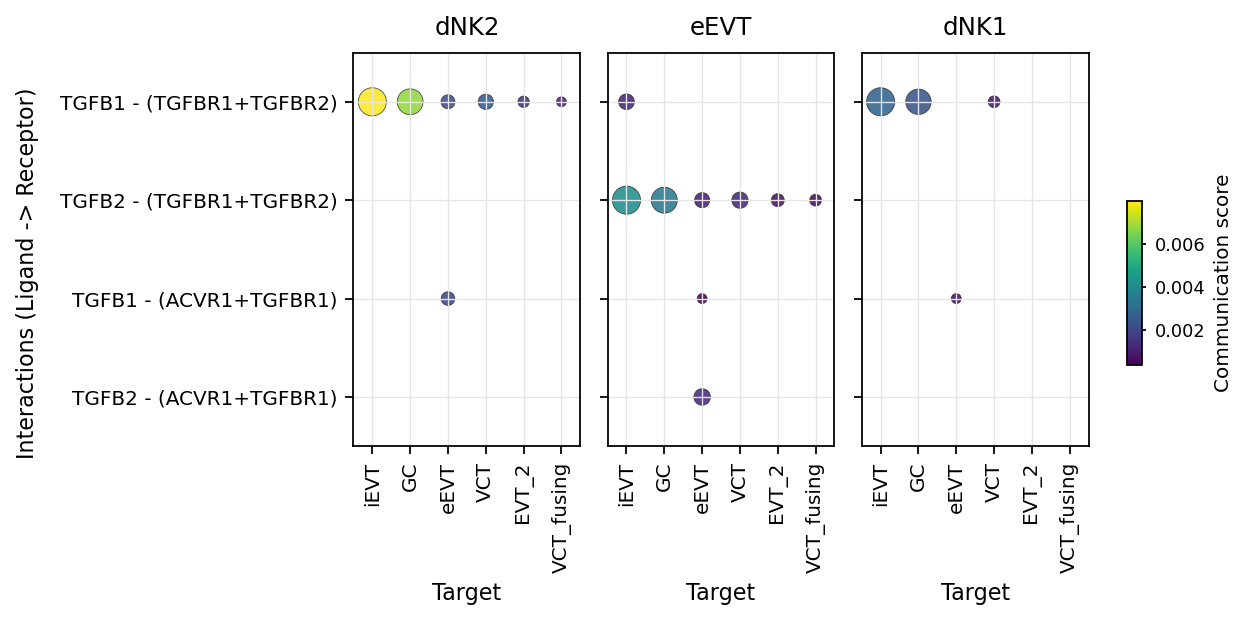

In [12]:
fig, ax = ov.pl.ccc_heatmap(
    adata, plot_type='dot', sender_use=['eEVT', 'dNK1', 'dNK2'], display_by='interaction',
    signaling=[focus_pathway], top_n=5, cmap='viridis', figsize=(8, 3), show=False,
)

⚠️  Warning: All p-values are identical. Adding slight jitter for better visualization.
⚠️  Warning: All p-values are identical after jittering. Using medium size.
📊 Visualization statistics:
   - Number of significant interactions: 10
   - Number of cell type pairs: 10
   - Signaling pathways: 1
   - Data scaling: None (raw expression values)
   - Color bars: sender


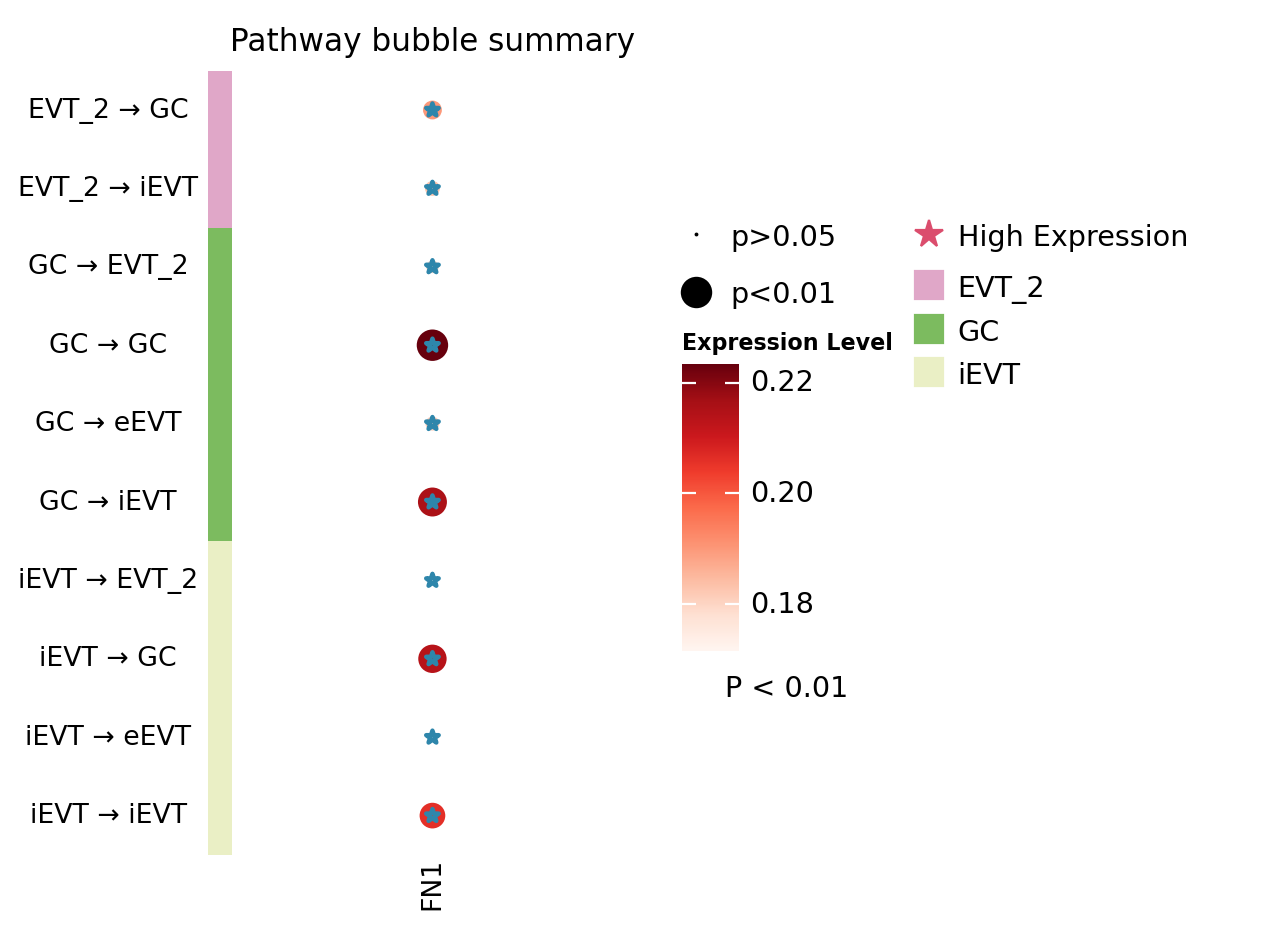

In [13]:
fig, ax = ov.pl.ccc_heatmap(
    adata, plot_type='pathway_bubble', signaling=['TGFb', 'COLLAGEN', 'FN1'],
    top_n=10, figsize=(4, 7), show=False,
)

🔬 Calculating cell communication strength for 226 pathways...
   - Aggregation method: mean
   - Minimum expression threshold: 2.2250738585072014e-308


✅ Completed pathway communication strength calculation for 226 pathways
📊 Pathway significance analysis results:
   - Total pathways: 226
   - Significant pathways: 74
   - Strength threshold: 0.0
   - p-value threshold: 0.05

🏆 Top 10 pathways by total strength:
----------------------------------------------------------------------------------------------------
Pathway                        Total    Max     Mean    L-R  Active Sig  Rate   Status
----------------------------------------------------------------------------------------------------
CypA                           4.51     0.08    0.03    1    156    79   0.51   ***
FN1                            4.40     0.14    0.03    13   143    130  0.91   ***
VEGF                           4.16     0.18    0.04    6    100    55   0.55   ***
ADGRG                          1.72     0.12    0.02    10   98     75   0.77   ***
NCAM                           1.54     0.15    0.04    3    40     40   1.00   ***
SPP1                       

📊 Heatmap statistics:
   - Number of pathways: 10
   - Number of cell types: 14
   - Signal strength range: 0.000 - 0.045


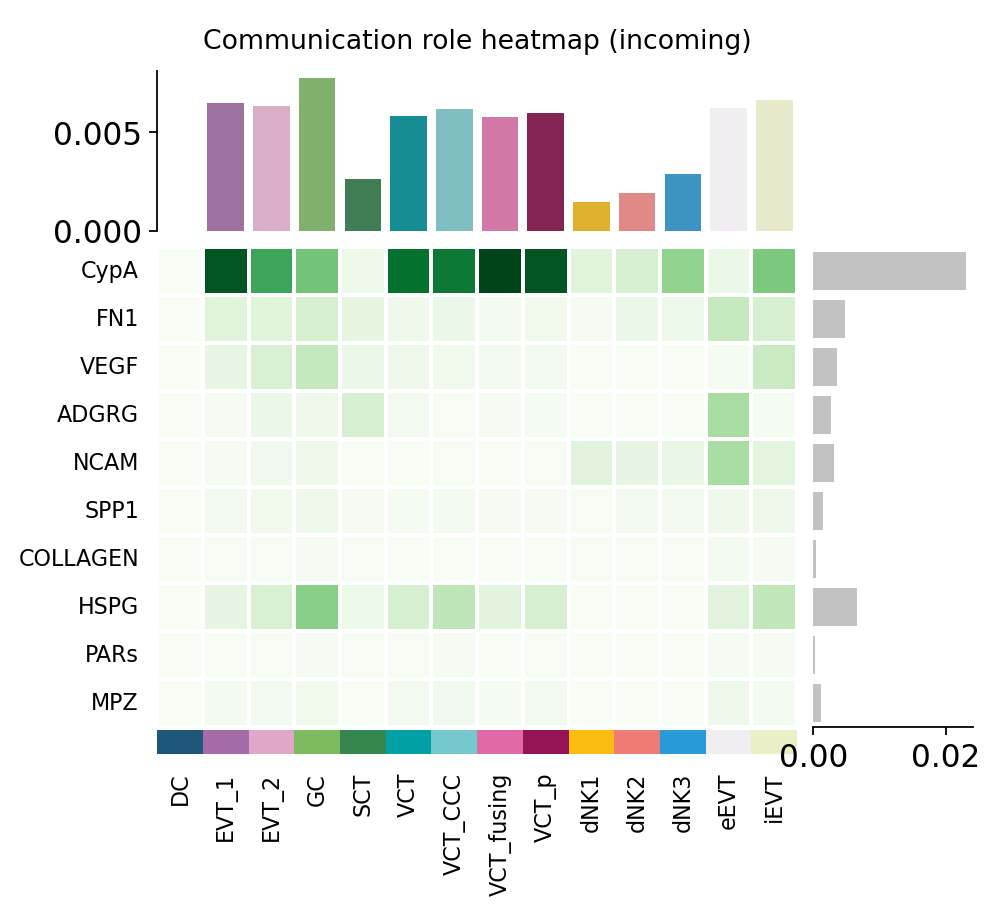

In [14]:
fig, ax = ov.pl.ccc_heatmap(
    adata, plot_type='role_heatmap', pattern='incoming', cmap='Greens',
    top_n=10, figsize=(4, 3), show=False,
)

✅ Network centrality calculation completed (CellChat-style Importance values)
   - Signaling pathways used: ['TGFb']
   - Weight mode: Weighted
   - Calculated metrics: outdegree, indegree, flow_betweenness, information, overall
   - All centrality scores normalized to 0-1 range (Importance values)


📊 Signaling role analysis results (Importance values 0-1):
   - Dominant Sender: EVT_1 (Importance: 1.000)
   - Dominant Receiver: iEVT (Importance: 1.000)
   - Mediator: eEVT (Importance: 1.000)
   - Influencer: EVT_1 (Importance: 1.000)


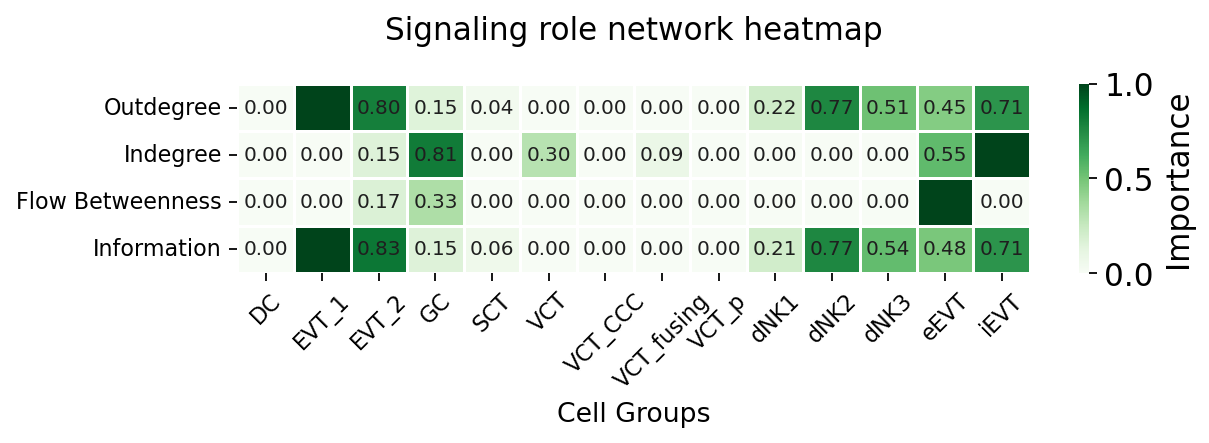

In [15]:
fig, ax = ov.pl.ccc_heatmap(
    adata, plot_type='role_network', signaling=[focus_pathway],
    cmap='Greens', figsize=(8, 3), show=False,
)

# 2. `ov.pl.ccc_network_plot`

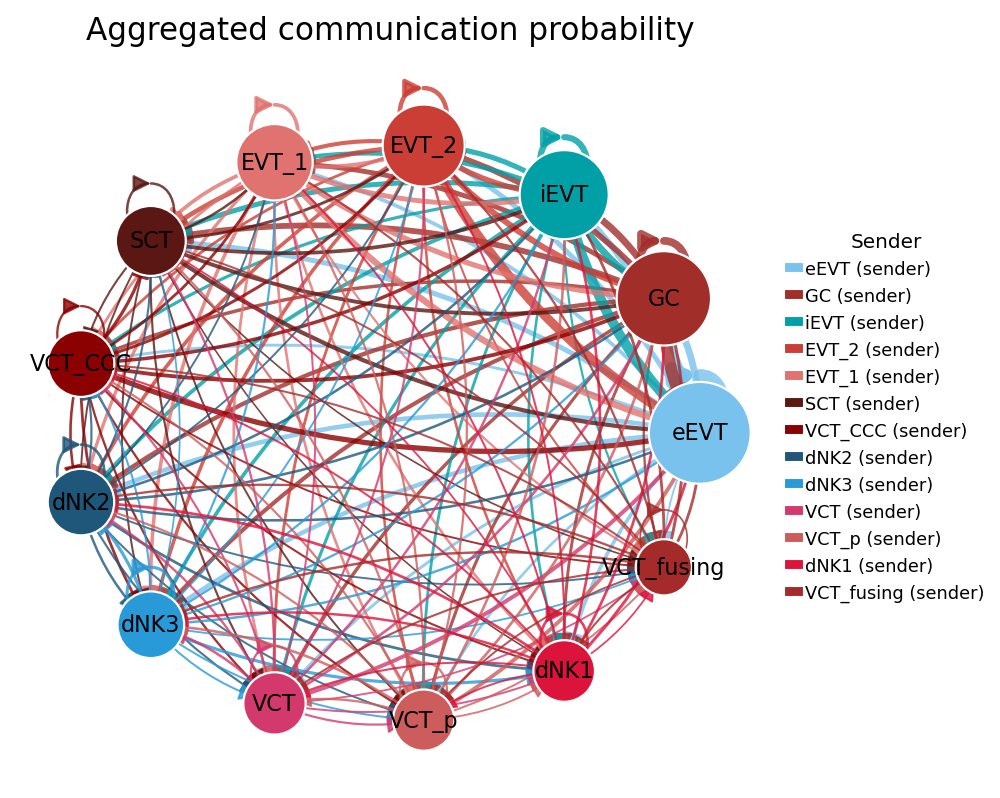

In [16]:
fig, ax = ov.pl.ccc_network_plot(
    adata, plot_type='circle', palette=color_dict,
    title='Aggregated communication probability', figsize=(6, 6), show=False,
)

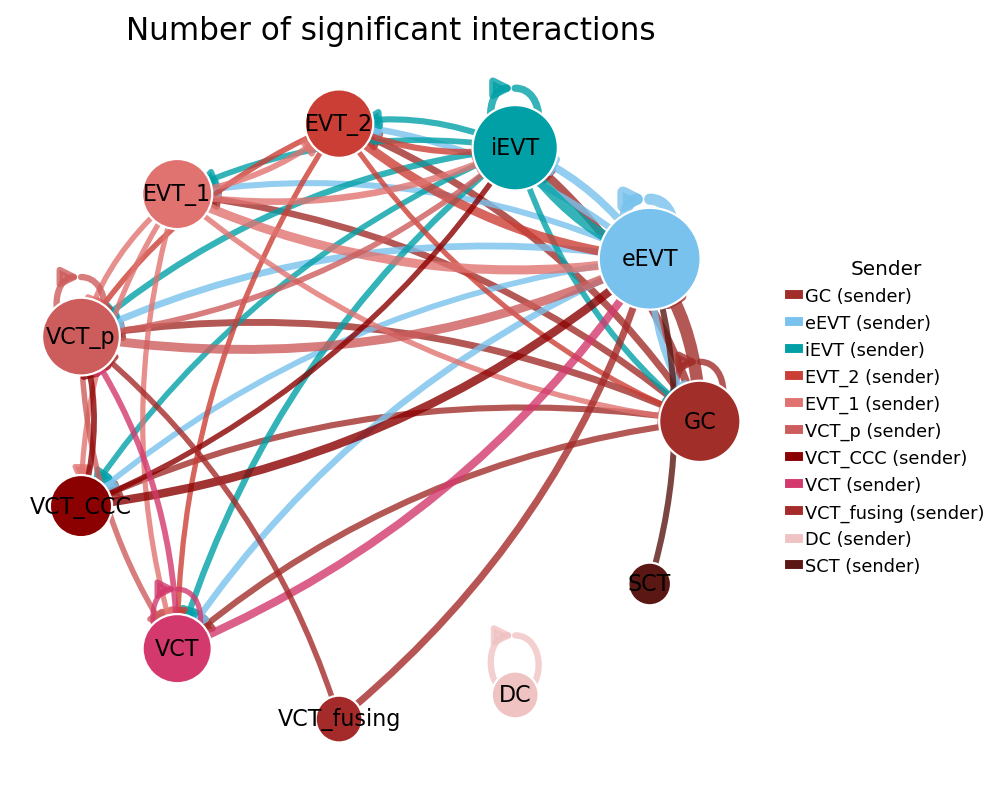

In [17]:
fig, ax = ov.pl.ccc_network_plot(
    adata, plot_type='circle', value='count', palette=color_dict, top_n=50,
    title='Number of significant interactions', figsize=(6, 6), show=False,
)

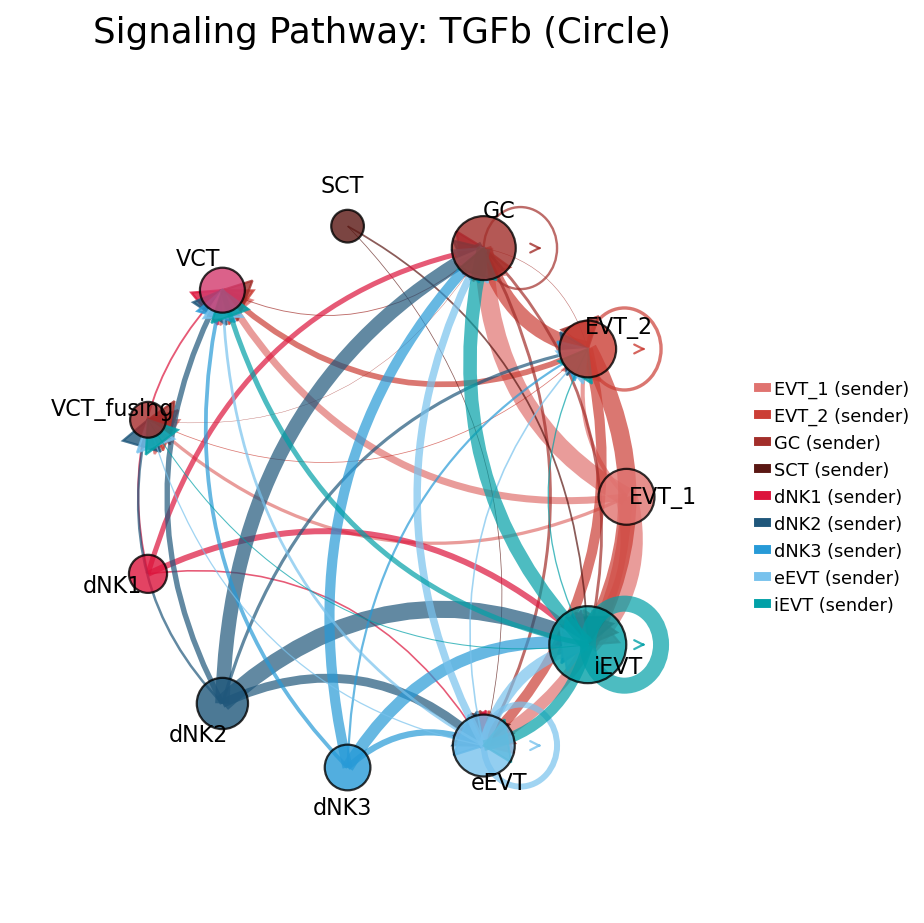

In [18]:
fig, ax = ov.pl.ccc_network_plot(
    adata, plot_type='pathway', signaling=[focus_pathway], palette=color_dict,
    top_n=50, figsize=(6, 6), show=False,
)

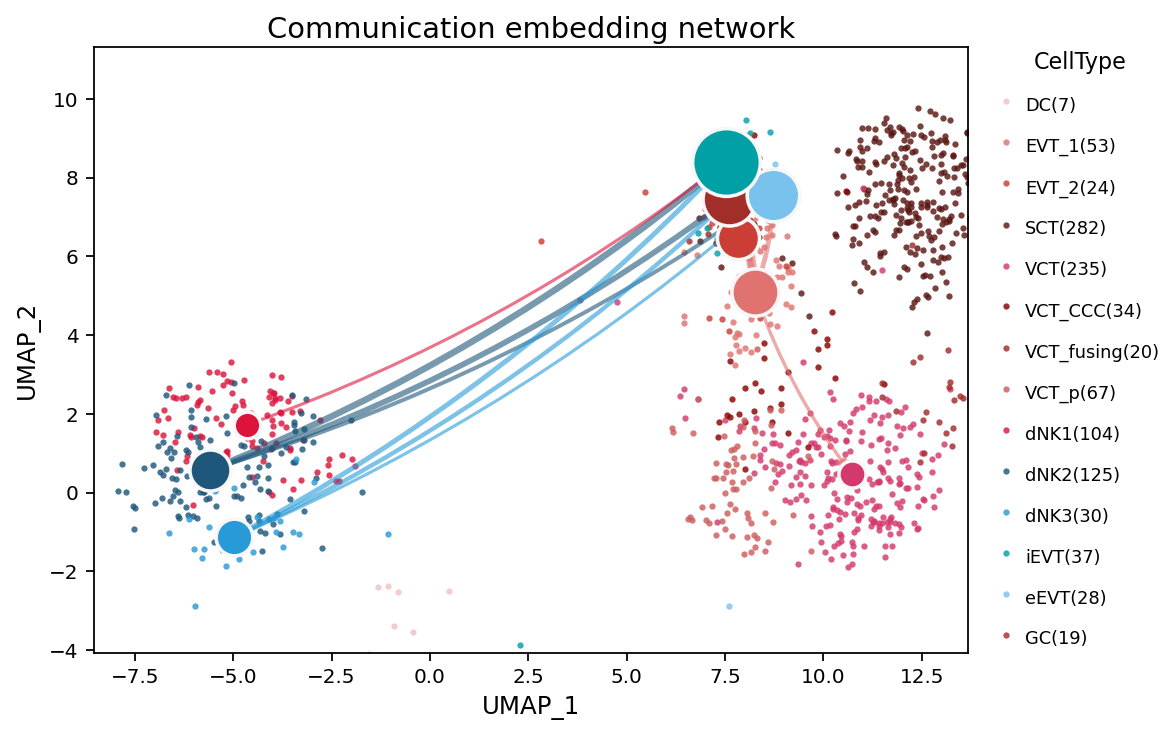

In [19]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata, plot_type='embedding_network', signaling=[focus_pathway],
    node_positions=node_positions, embedding_points=umap_df, palette=color_dict,
    top_n=20, figsize=(7, 5), show=False,
)

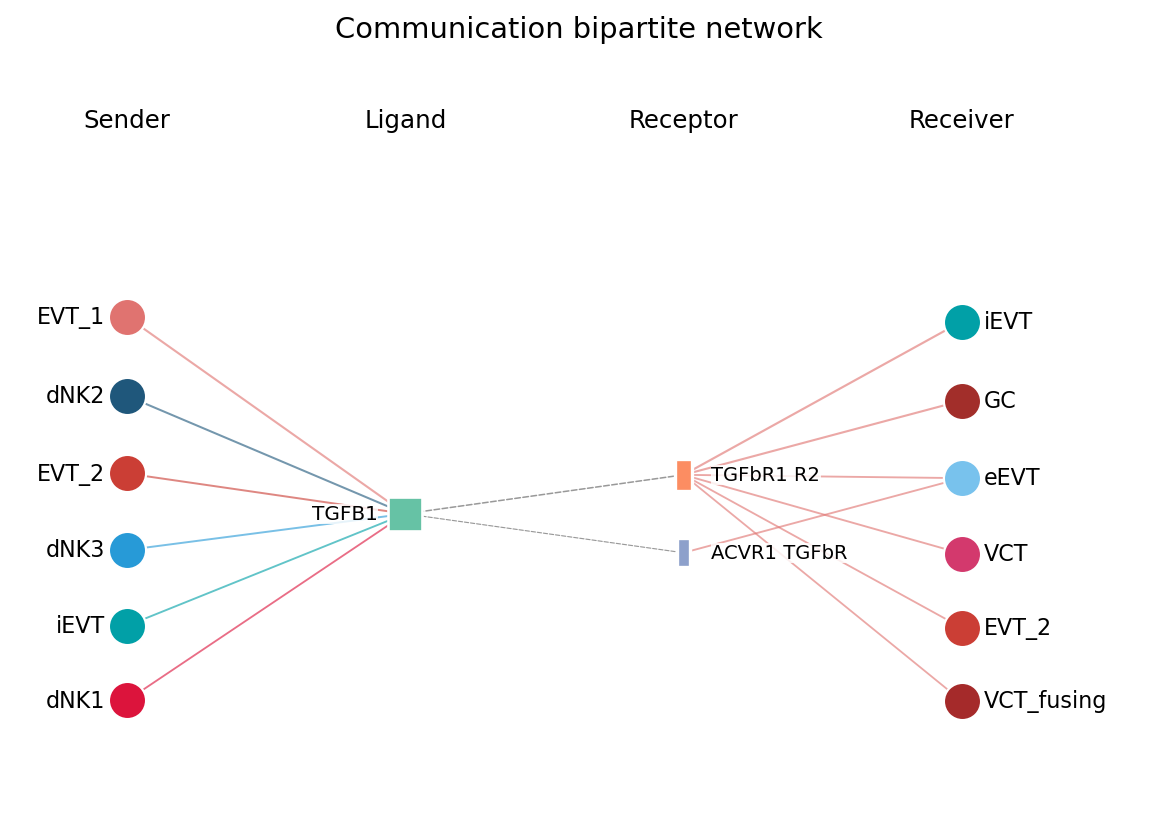

In [20]:
fig, ax = ov.pl.ccc_network_plot(
    adata, plot_type='bipartite', ligand=focus_ligand, palette=color_dict,
    top_n=6, figsize=(8, 6), show=False,
)

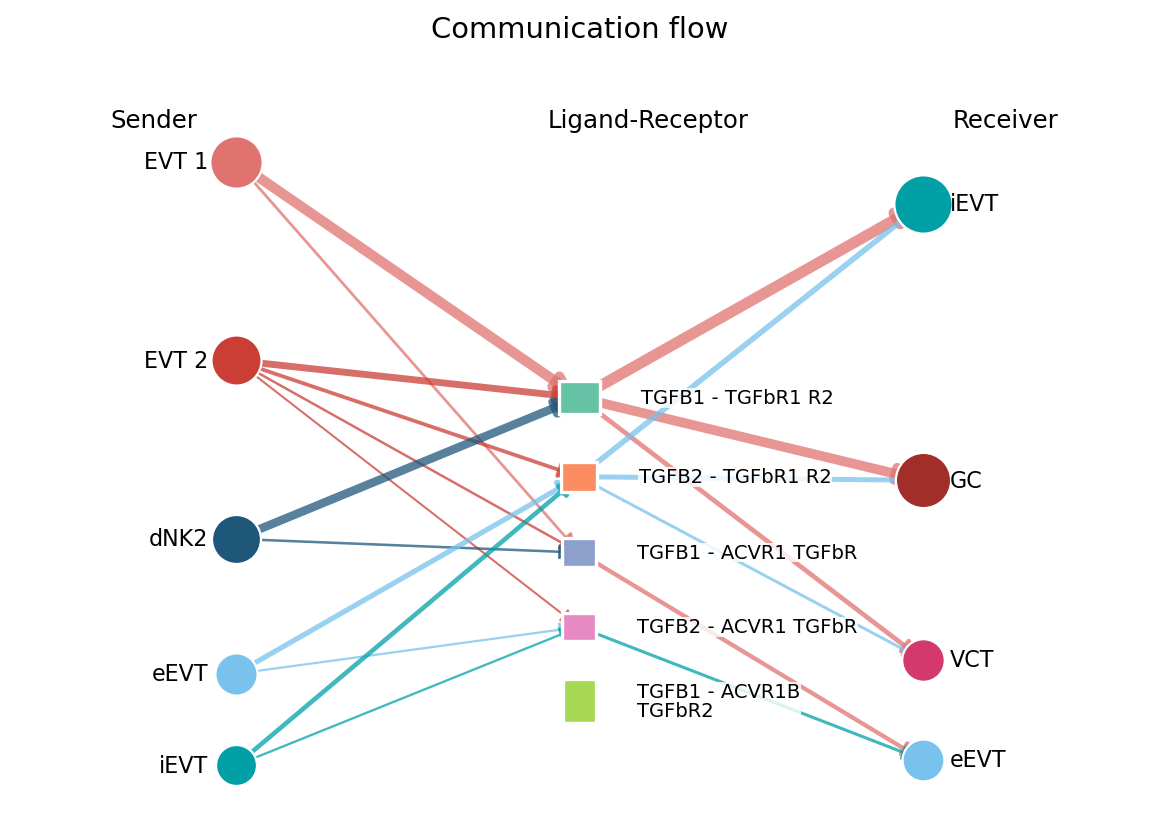

In [21]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata, plot_type='arrow', display_by='interaction', signaling=[focus_pathway],
    palette=color_dict, top_n=5, figsize=(8, 6), show=False,
)

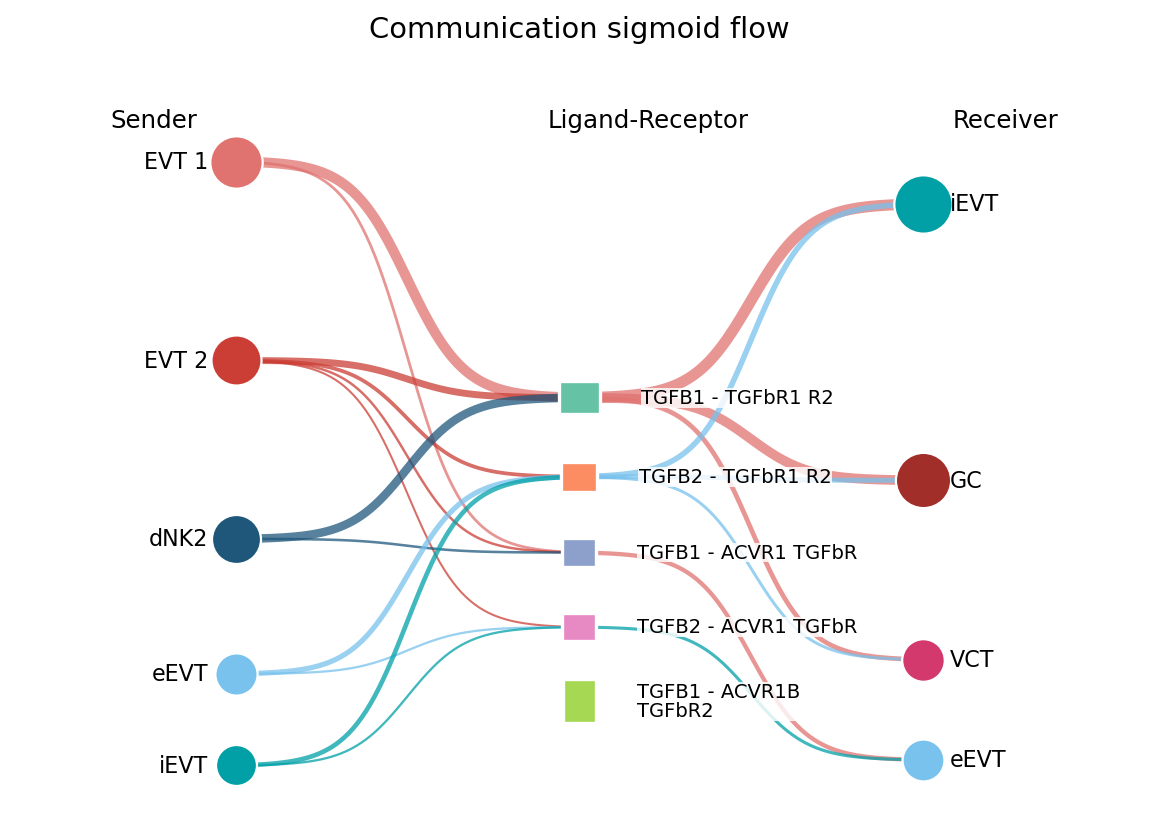

In [22]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata, plot_type='sigmoid', display_by='interaction', signaling=[focus_pathway],
    palette=color_dict, top_n=5, figsize=(8, 6), show=False,
)

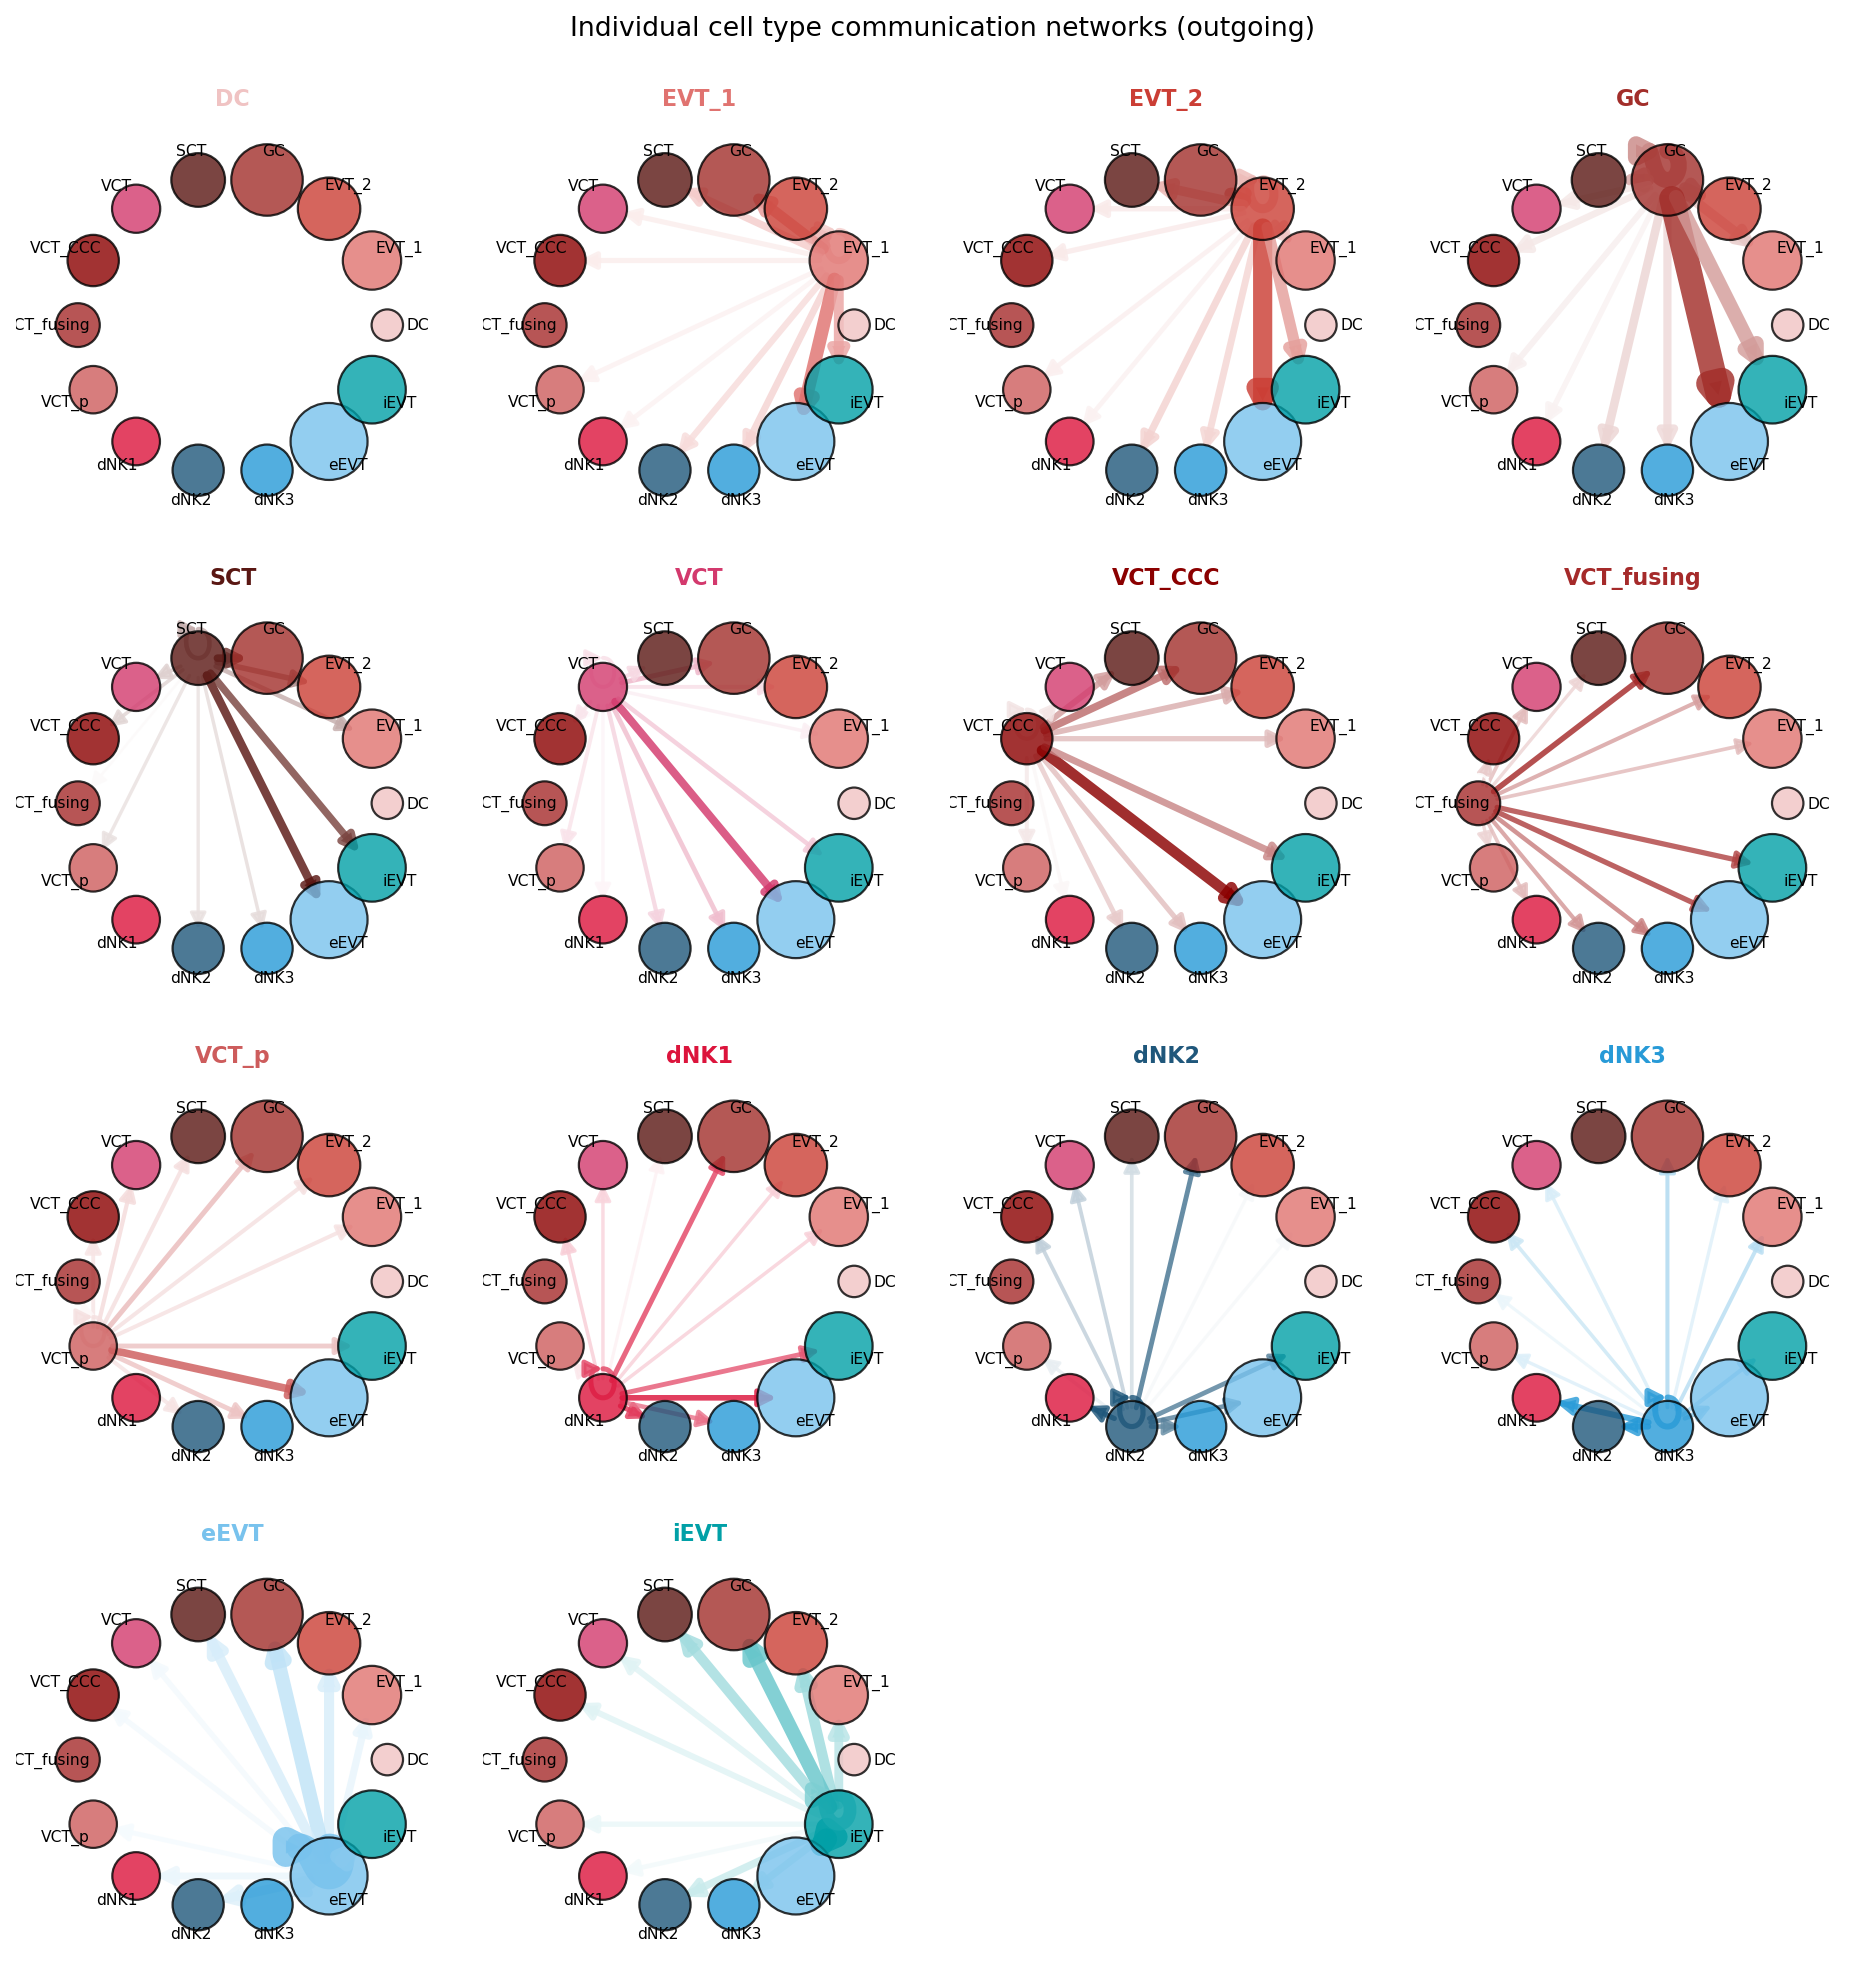

In [23]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata, plot_type='individual_outgoing', palette=color_dict,
    figsize=(12, 13), show=False,
)

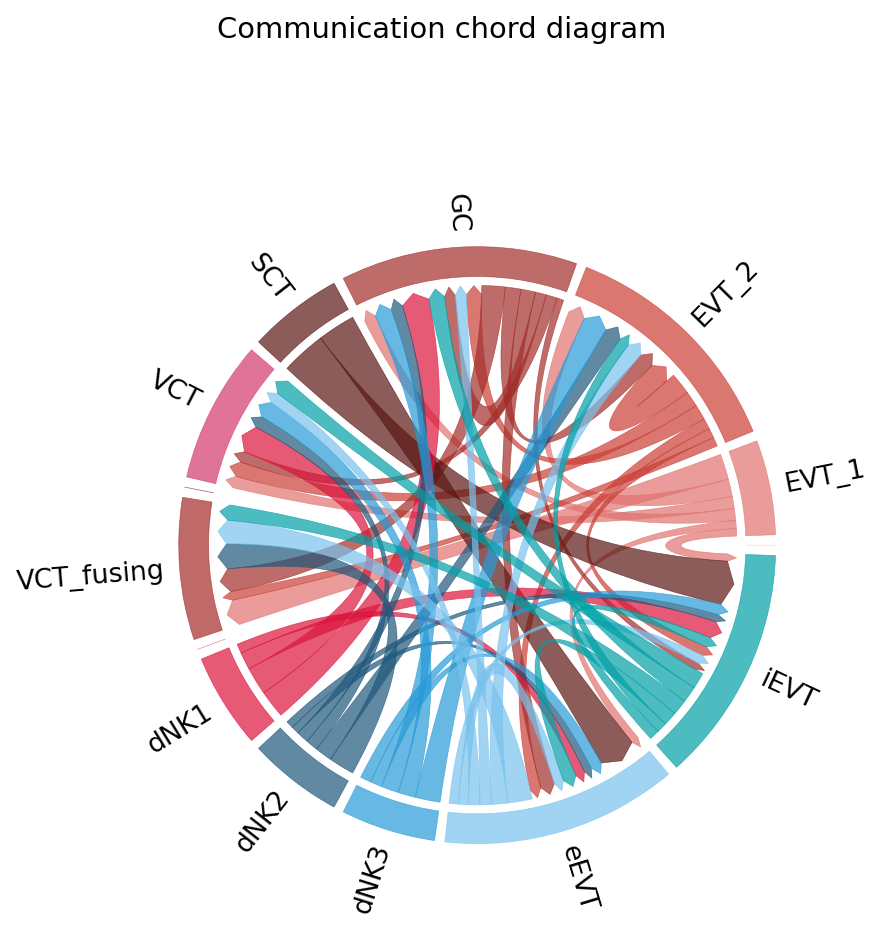

In [24]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata, plot_type='chord', signaling=[focus_pathway], palette=color_dict,
    normalize_to_sender=True, figsize=(6, 6), show=False,
)

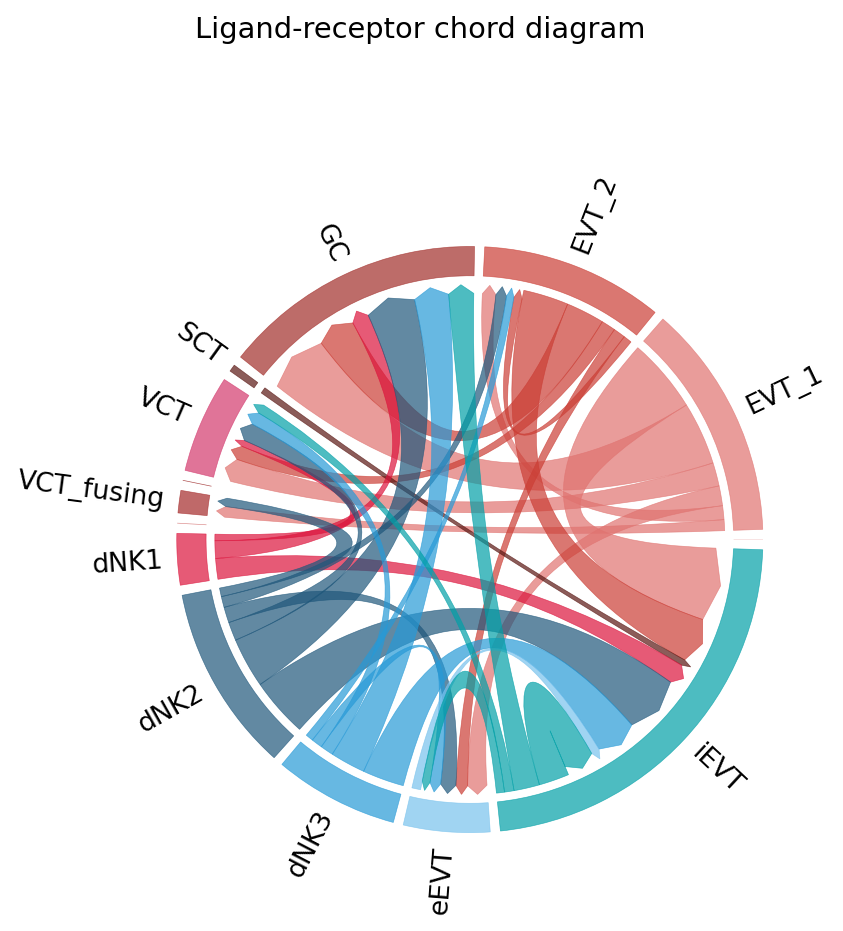

In [25]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata, plot_type='lr_chord', pair_lr_use=focus_pair_lr, palette=color_dict,
    figsize=(6, 6), show=False,
)

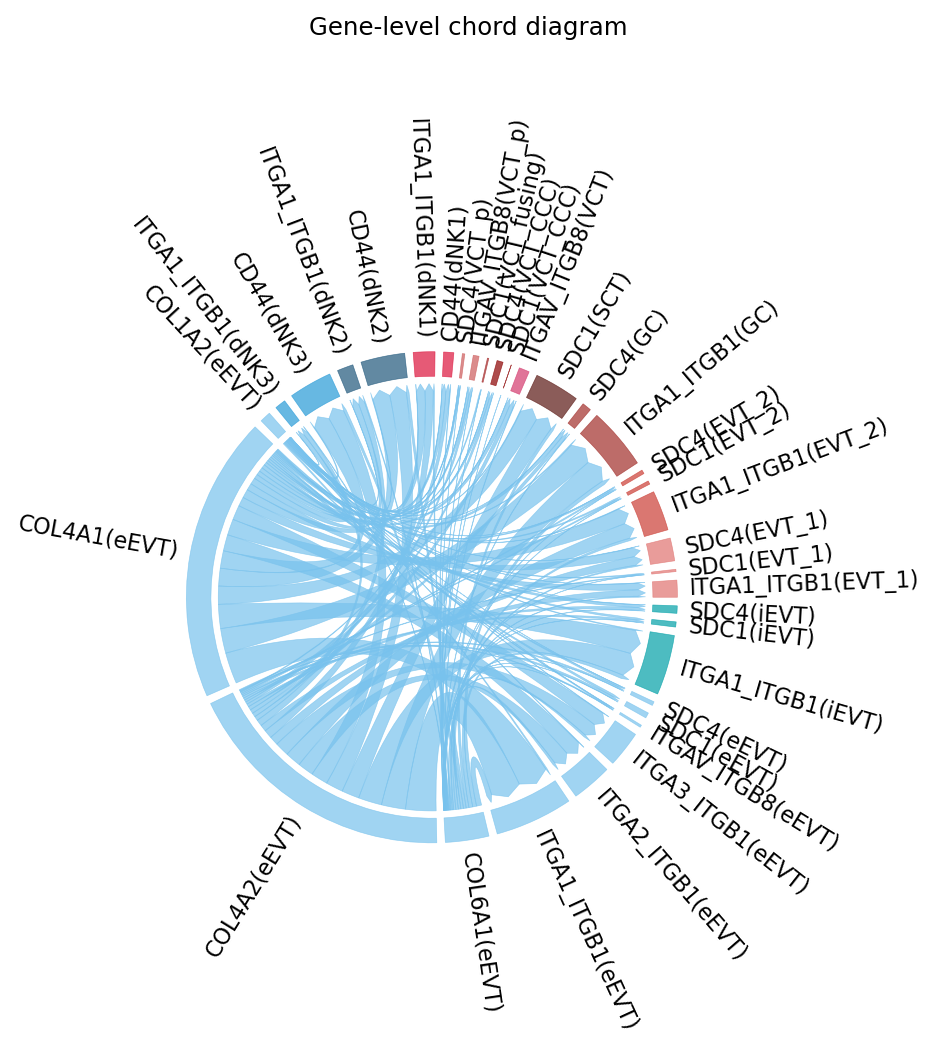

In [26]:
fig, ax = ov.pl.ccc_network_plot(
    comm_adata, plot_type='gene_chord', signaling=['COLLAGEN'], sender_use=['eEVT', 'dNK1'],
    palette=color_dict, figsize=(6, 7), show=False,
)

# 3. `ov.pl.ccc_stat_plot`

CellChat scores are probabilities (≈1e-3), not expression levels, so pathway summaries use scale-aware defaults for CellChat results: a pathway counts as significant when it has a permutation p-value < 0.05, as in R. `pathway_method='sum'` ranks pathways by their summed probability, which is how CellChat ranks `netP`.

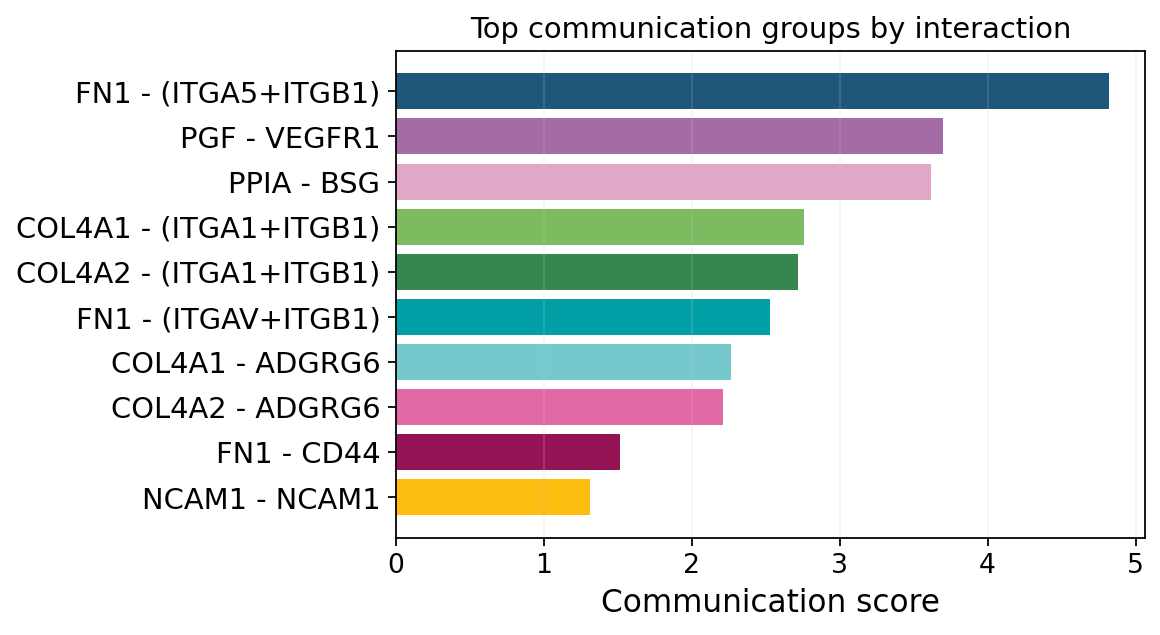

In [27]:
fig, ax = ov.pl.ccc_stat_plot(
    adata, plot_type='bar', figsize=(6, 4), top_n=10, show=False,
)

✅ Network centrality calculation completed (CellChat-style Importance values)
   - Signaling pathways used: All pathways
   - Weight mode: Weighted
   - Calculated metrics: outdegree, indegree, flow_betweenness, information, overall
   - All centrality scores normalized to 0-1 range (Importance values)


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


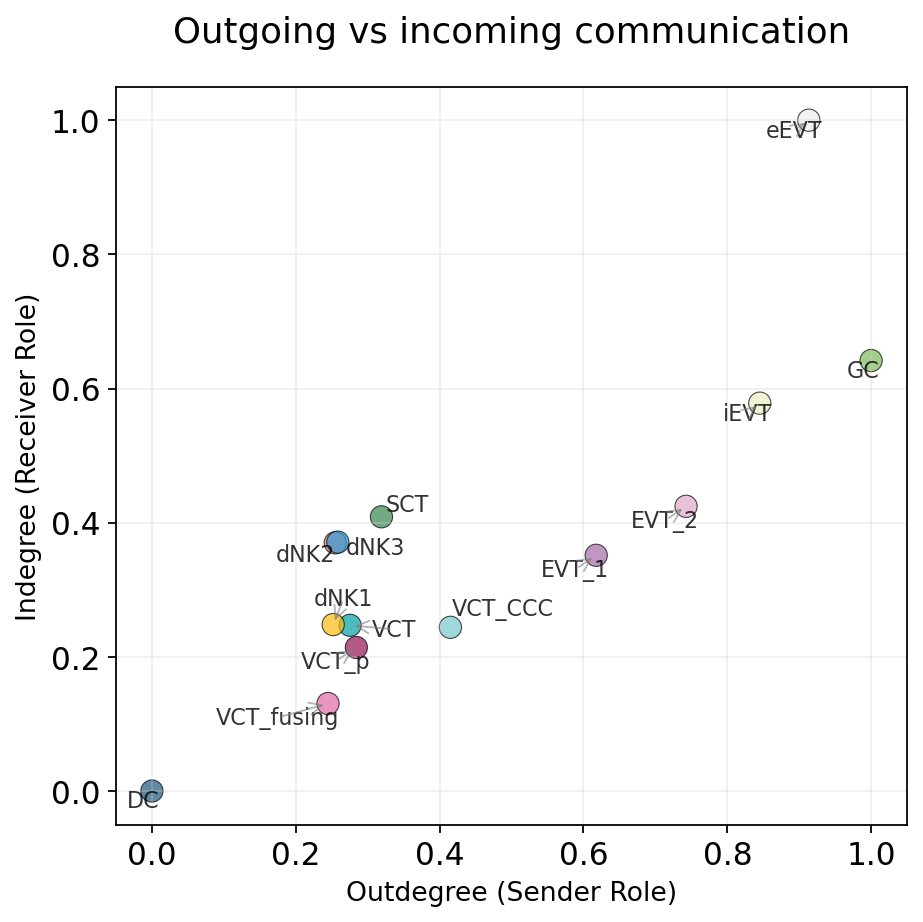

In [28]:
fig, ax = ov.pl.ccc_stat_plot(
    adata, plot_type='scatter', figsize=(6, 6), show=False,
)

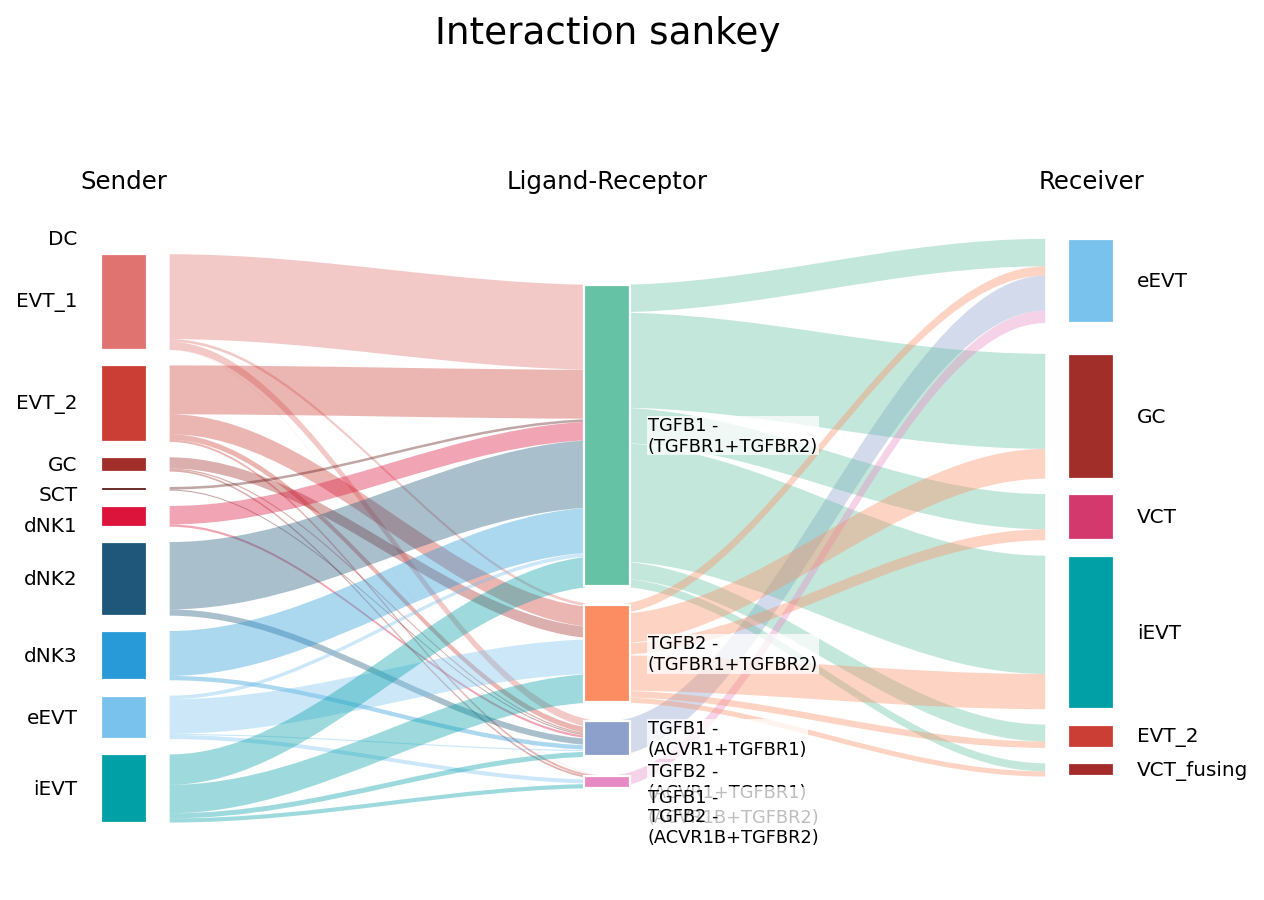

In [29]:
fig, ax = ov.pl.ccc_stat_plot(
    adata, plot_type='sankey', display_by='interaction', signaling=[focus_pathway],
    palette=color_dict, top_n=8, figsize=(8, 6), show=False,
)

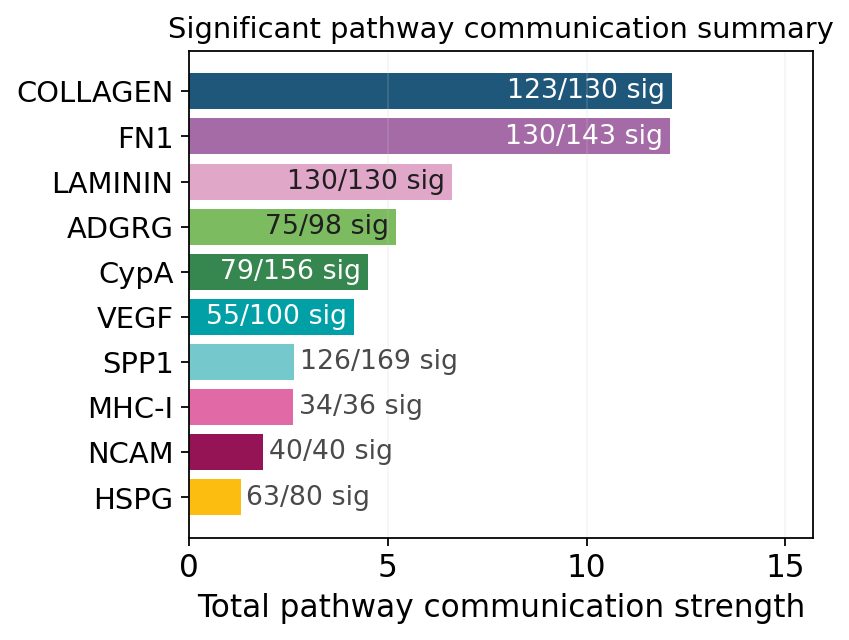

In [30]:
fig, ax = ov.pl.ccc_stat_plot(
    adata, plot_type='pathway_summary', pathway_method='sum', top_n=10,
    figsize=(5, 4), verbose=False, show=False,
)

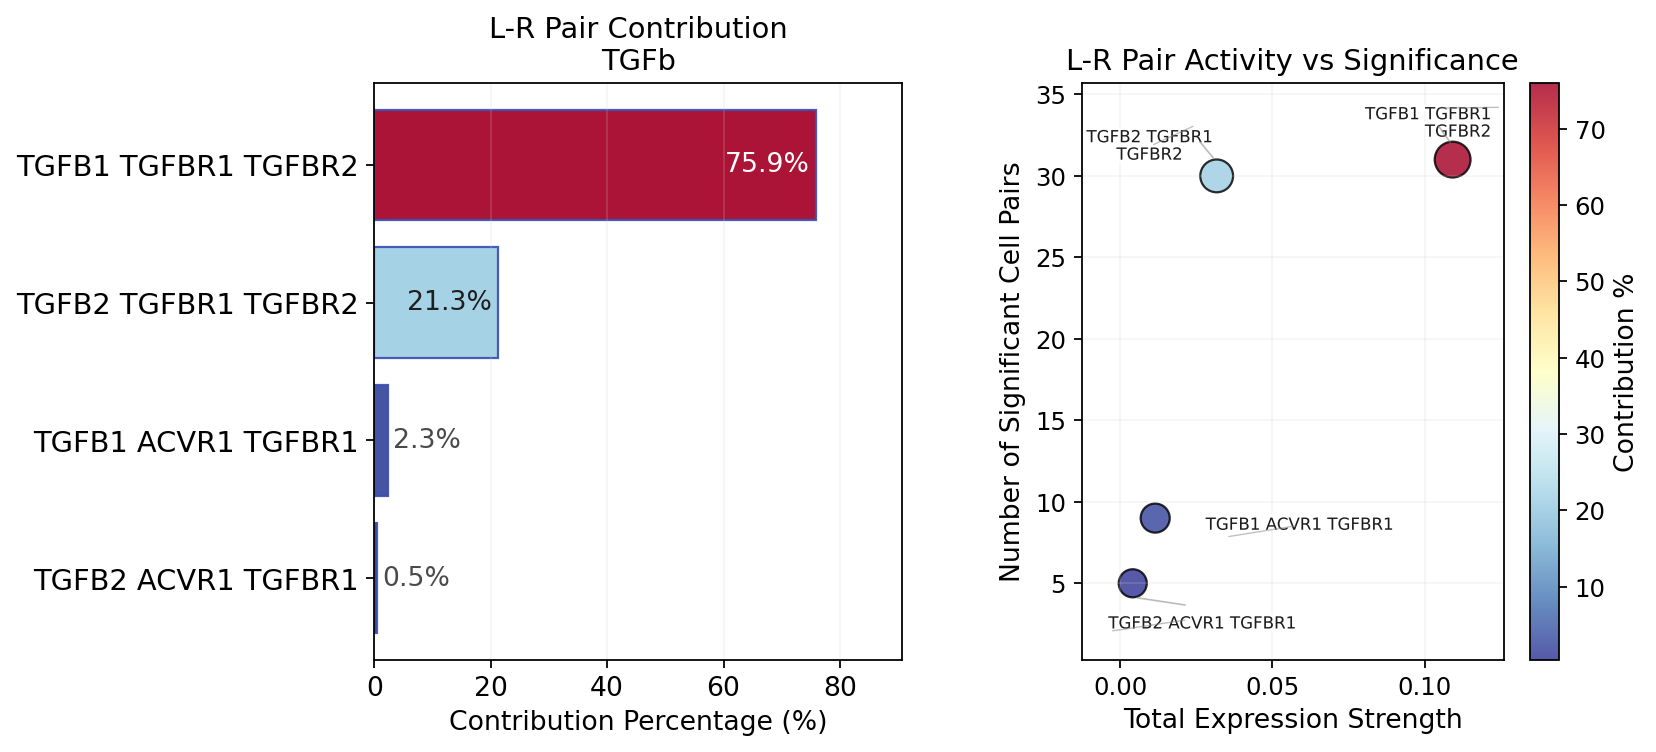

In [31]:
fig, ax = ov.pl.ccc_stat_plot(
    adata, plot_type='lr_contribution', signaling=[focus_pathway],
    figsize=(10, 5), show=False,
)

# 4. CellChat network analysis
## 4.1 Signaling roles

`ov.single.cellchat_centrality` ports `netAnalysis_computeCentrality`: for every pathway it scores each cell group as **sender** (weighted out-degree), **receiver** (in-degree), **mediator** (flow betweenness) and **influencer** (information centrality), plus hub/authority, eigenvector, PageRank and betweenness.

In [32]:
centr = ov.single.cellchat_centrality(adata)
roles = centr[focus_pathway][['outdeg', 'indeg', 'flowbet', 'info']]
roles.columns = ['Sender', 'Receiver', 'Mediator', 'Influencer']
roles.round(3)

,Sender,Receiver,Mediator,Influencer
DC,0.000,0.000,0.000,0.000
EVT_1,0.031,0.000,0.000,0.000
EVT_2,0.025,0.008,0.040,0.087
GC,0.005,0.042,0.032,0.166
SCT,0.001,0.000,0.000,0.000
VCT,0.000,0.015,0.000,0.113
VCT_CCC,0.000,0.000,0.000,0.000
VCT_fusing,0.000,0.004,0.000,0.047
VCT_p,0.000,0.000,0.000,0.000
dNK1,0.007,0.000,0.000,0.061


## 4.2 Communication patterns

`ov.single.cellchat_communication_patterns` factorises the cell-group × pathway signaling matrix with NMF (R `identifyCommunicationPatterns`). `W` gives each group's loading on a pattern, `H` each pathway's; below each pathway is assigned to its dominant pattern.

In [33]:
W, H = ov.single.cellchat_communication_patterns(adata, k=3, pattern='outgoing')
W.round(2)

,Pattern 1,Pattern 2,Pattern 3
EVT_1,0.48,0.34,0.18
EVT_2,0.85,0.00,0.15
GC,1.00,0.00,0.00
SCT,1.00,0.00,0.00
VCT,0.24,0.76,0.00
VCT_CCC,0.33,0.67,0.00
VCT_fusing,0.36,0.64,0.00
VCT_p,0.20,0.80,0.00
dNK1,0.00,0.04,0.96
dNK2,0.01,0.01,0.98


In [34]:
dominant = H.idxmax(axis=0)
dominant.groupby(dominant).apply(lambda s: ', '.join(s.index[:12]))

Pattern 1    COLLAGEN, FN1, LAMININ, ADGRG, VEGF, HSPG, PTN...
Pattern 2    MIF, Prostaglandin, DESMOSOME, MK, CDH, CDH1, ...
Pattern 3    CypA, MHC-I, SPP1, NCAM, PARs, EGF, CD99, SEMA...
dtype: object

## Summary

- `ov.single.run_cellchat` runs the full R CellChat workflow in PyTorch on CPU or GPU and stores everything in `adata.uns['cellchat_res']`.
- All `ov.pl.ccc_*` plots accept the CellChat result directly, so CellChat, CellPhoneDB and LIANA+ results can be visualised and compared with the same calls.
- CellChat is the most conservative of the three methods: it requires both ligand and receptor to be over-expressed and down-weights interactions with antagonists or inhibitory co-receptors, so it reports fewer but more specific interactions than CellPhoneDB or LIANA+.

**Citation:** Jin S. *et al.* Inference and analysis of cell-cell communication using CellChat. *Nat Commun* 12, 1088 (2021); Jin S., Plikus M.V., Nie Q. CellChat for systematic analysis of cell-cell communication from single-cell transcriptomics. *Nat Protoc* (2025).